# pSMAD — 02c_manual_bead_well_annotation

**Feeds:** Fig 1e, 1f

**Position in the chain:** run the numbered notebooks in order

Ported unchanged from the original analysis: outputs are as they ran, and no code
cell was edited. Paths appear as `<analysis-root>/...`.


# 02c | Manual Bead-Well Annotation + ROI JSON Build (36 Locations)

This notebook is the human-in-the-loop follow-up to `02b_auto_roi_from_dapi.ipynb`.

It does four things:
- loads the scene manifest, scene TIFF exports, and cyst-label TIFFs created by `02b`
- lets you click one bead-well centroid per scene
- writes `manual_bead_well_positions_36locations.tsv`
- writes one ROI JSON per cyst, mapped to the manual bead-well coordinate for that scene

## Cell Guide

1. Imports.
2. Settings (paths/output controls).
3. Helper functions shared by the manual annotation workflow.
4. Load the scene manifest written by `02b` and confirm scene coverage.
5. Run the interactive bead-well click widget.
6. Check annotation coverage.
7. Build ROI JSON records from cyst labels + manual bead-well coordinates.
8. Preview all 36 scenes with cyst labels + transparent bead-well marker.

In [ ]:
import os
import json
from datetime import datetime, timezone
from pathlib import Path

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from IPython import get_ipython
from IPython.display import display
from matplotlib.patches import Circle
from skimage import color, draw, measure

In [ ]:
# -------------------------------
# Project + run settings
# -------------------------------
ROOT = Path.cwd().resolve()
if not (ROOT / "scripts").exists() and (ROOT.parent / "scripts").exists():
    ROOT = ROOT.parent.resolve()

OUT_BASE_DIR = ROOT / "results/manual_bead_well_36locations"
OUT_SCENE_DIR = OUT_BASE_DIR / "scene_images"
OUT_LABEL_DIR = OUT_BASE_DIR / "labels"
OUT_ROI_DIR = ROOT / "results/rois/manual_bead_well_36locations"
OUT_TABLE_DIR = ROOT / "results/tables"

SCENE_MANIFEST_TSV = OUT_TABLE_DIR / "scene_manifest_36locations.tsv"
BEAD_WELL_TSV = OUT_TABLE_DIR / "manual_bead_well_positions_36locations.tsv"
ROI_SUMMARY_TSV = OUT_TABLE_DIR / "manual_roi_summary_36locations.tsv"

BEAD_WELL_RADIUS_PX = 107.5  # approx 215 px diameter / 2
REQUIRE_36_SCENES = True
SCENE_OVERLAY_DOWNSAMPLE = 2
SCENE_OVERLAY_GRID_COLS = 6
OVERWRITE_ROI_JSON = True

for p in [OUT_BASE_DIR, OUT_SCENE_DIR, OUT_LABEL_DIR, OUT_ROI_DIR, OUT_TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Scene manifest TSV:", SCENE_MANIFEST_TSV)
print("Manual bead TSV:", BEAD_WELL_TSV)
print("ROI output dir:", OUT_ROI_DIR)

Project root: <analysis-root>/pSMAD
Scene manifest TSV: <analysis-root>/pSMAD/results/tables/scene_manifest_36locations.tsv
Manual bead TSV: <analysis-root>/pSMAD/results/tables/manual_bead_well_positions_36locations.tsv
ROI output dir: <analysis-root>/pSMAD/results/rois/manual_bead_well_36locations


## Settings Notes

- Run notebook `02b_auto_roi_from_dapi.ipynb` first. This notebook assumes the scene manifest, scene image TIFFs, and cyst-label TIFFs already exist.
- The widget writes to `manual_bead_well_positions_36locations.tsv` immediately after each save/pass action.
- ROI JSON files are rebuilt from the current bead TSV and the current cyst-label TIFFs.

In [ ]:
# -------------------------------
# Manual-annotation helper functions
# -------------------------------
def normalize_for_display(
    img: np.ndarray, p_lo: float = 2, p_hi: float = 99.8
) -> np.ndarray:
    """Percentile normalization for plotting only."""
    finite = img[np.isfinite(img)]
    lo, hi = np.percentile(finite, [p_lo, p_hi])
    den = max(1e-6, float(hi - lo))
    return np.clip((img - lo) / den, 0, 1)


def mask_to_polygon_xy(
    mask: np.ndarray, simplify_tolerance_px: float = 1.5, min_points: int = 8
) -> list[list[float]]:
    """Convert a binary mask to [x, y] polygon vertices."""
    contours = measure.find_contours(mask.astype(np.uint8), 0.5)
    if not contours:
        return []
    contour = max(contours, key=lambda c: c.shape[0])
    if simplify_tolerance_px > 0:
        contour = measure.approximate_polygon(contour, tolerance=simplify_tolerance_px)
    pts = [[float(col), float(row)] for row, col in contour]
    if len(pts) < min_points:
        return []
    return pts


def rel_to_root(path: Path) -> str:
    """Store paths relative to project root when possible."""
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except Exception:
        return str(path.resolve())


def load_or_init_bead_table(
    table_path: Path, scene_manifest_df: pd.DataFrame, write_if_missing: bool = True
) -> pd.DataFrame:
    """Load bead annotation TSV if present; otherwise initialize one row per scene."""
    base_cols = [
        "source_file",
        "source_ome_path",
        "scene_index",
        "scene_name",
        "scene",
        "brightfield_image_path",
        "dapi_image_path",
        "psmad_image_path",
        "bead_image_path",
        "cyst_labels_path",
        "pixel_size_um",
        "n_cysts_detected",
        "expected_cysts",
        "bead_well_x_px",
        "bead_well_y_px",
        "bead_well_radius_px",
        "status",
        "annotator",
        "updated_at_utc",
    ]

    base = scene_manifest_df.copy()
    base["bead_well_x_px"] = np.nan
    base["bead_well_y_px"] = np.nan
    base["bead_well_radius_px"] = float(BEAD_WELL_RADIUS_PX)
    base["status"] = "unlabeled"
    base["annotator"] = ""
    base["updated_at_utc"] = ""

    if table_path.exists():
        old = pd.read_csv(table_path, sep="	")
        if "scene_index" not in old.columns:
            raise ValueError(f"Existing bead TSV missing 'scene_index': {table_path}")
        old = old.sort_values("scene_index").drop_duplicates("scene_index", keep="last")
        merge_cols = [
            "scene_index",
            "bead_well_x_px",
            "bead_well_y_px",
            "bead_well_radius_px",
            "status",
            "annotator",
            "updated_at_utc",
        ]
        keep_old = [c for c in merge_cols if c in old.columns]
        old = old[keep_old].copy()
        base = base.drop(
            columns=[c for c in merge_cols if c != "scene_index" and c in base.columns]
        ).merge(old, on="scene_index", how="left")
        if "bead_well_radius_px" in base.columns:
            base["bead_well_radius_px"] = base["bead_well_radius_px"].fillna(
                float(BEAD_WELL_RADIUS_PX)
            )
        if "status" in base.columns:
            base["status"] = base["status"].fillna("unlabeled")
        for c in ["annotator", "updated_at_utc"]:
            if c in base.columns:
                base[c] = base[c].fillna("")

    for col in base_cols:
        if col not in base.columns:
            base[col] = (
                "" if col in {"status", "annotator", "updated_at_utc"} else np.nan
            )

    out = base[base_cols].sort_values("scene_index").reset_index(drop=True)
    if write_if_missing:
        out.to_csv(table_path, sep="	", index=False)
    return out

In [ ]:
# -------------------------------
# Load scene manifest written by notebook 02b
# -------------------------------
assert (
    SCENE_MANIFEST_TSV.exists()
), f"Missing scene manifest: {SCENE_MANIFEST_TSV}. Run 02b_auto_roi_from_dapi.ipynb first."

scene_manifest_df = (
    pd.read_csv(SCENE_MANIFEST_TSV, sep="	")
    .sort_values("scene_index")
    .reset_index(drop=True)
)

if REQUIRE_36_SCENES and len(scene_manifest_df) != 36:
    raise RuntimeError(
        f"Expected 36 scenes in {SCENE_MANIFEST_TSV.name}, found {len(scene_manifest_df)}."
    )

print("Scenes loaded from manifest:", len(scene_manifest_df))
print("Scene images dir:", OUT_SCENE_DIR)
print("Label dir:", OUT_LABEL_DIR)
display(
    scene_manifest_df[
        [
            "scene_index",
            "scene_name",
            "n_cysts_detected",
            "expected_cysts",
            "brightfield_image_path",
            "cyst_labels_path",
        ]
    ].head(10)
)

Scenes loaded from manifest: 36
Scene images dir: <analysis-root>/pSMAD/results/manual_bead_well_36locations/scene_images
Label dir: <analysis-root>/pSMAD/results/manual_bead_well_36locations/labels


   scene_index                 scene_name  n_cysts_detected  expected_cysts  \
0            0  well3-36locations.czi #01                 7               7   
1            1  well3-36locations.czi #02                 7               7   
2            2  well3-36locations.czi #03                 7               7   
3            3  well3-36locations.czi #04                 7               7   
4            4  well3-36locations.czi #05                 6               6   
5            5  well3-36locations.czi #06                 7               7   
6            6  well3-36locations.czi #07                 7               7   
7            7  well3-36locations.czi #08                 6               6   
8            8  well3-36locations.czi #09                 7               7   
9            9  well3-36locations.czi #10                 7               7   

                              brightfield_image_path  \
0  results/manual_bead_well_36locations/scene_ima...   
1  results/manual_


## Manual Bead-Well Annotation Widget

Use this for one centroid click per scene:
1. Click the bead-containing well center in any panel.
2. Press **Save Point + Next**.
3. Use **Pass** only if a scene is truly not annotatable.

Controls:
- **Prev / Next**: navigate scenes.
- **Clear Point**: clear current scene to unlabeled.
- **Save Point + Next**: writes TSV immediately.
- **Pass**: writes status as `passed` with empty coordinates.

The TSV is updated immediately on each action: `manual_bead_well_positions_36locations.tsv`.


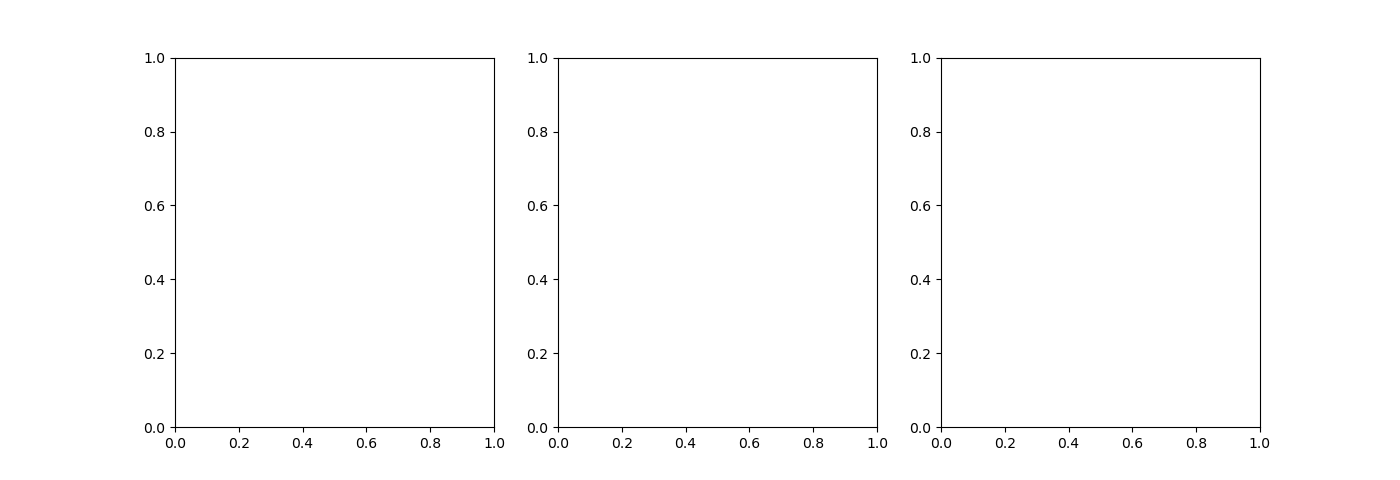

Annotation file: <analysis-root>/pSMAD/results/tables/manual_bead_well_positions_36locations.tsv
Tip: after annotation, rerun the next cells to refresh coverage, build ROI JSON, and render final montage.


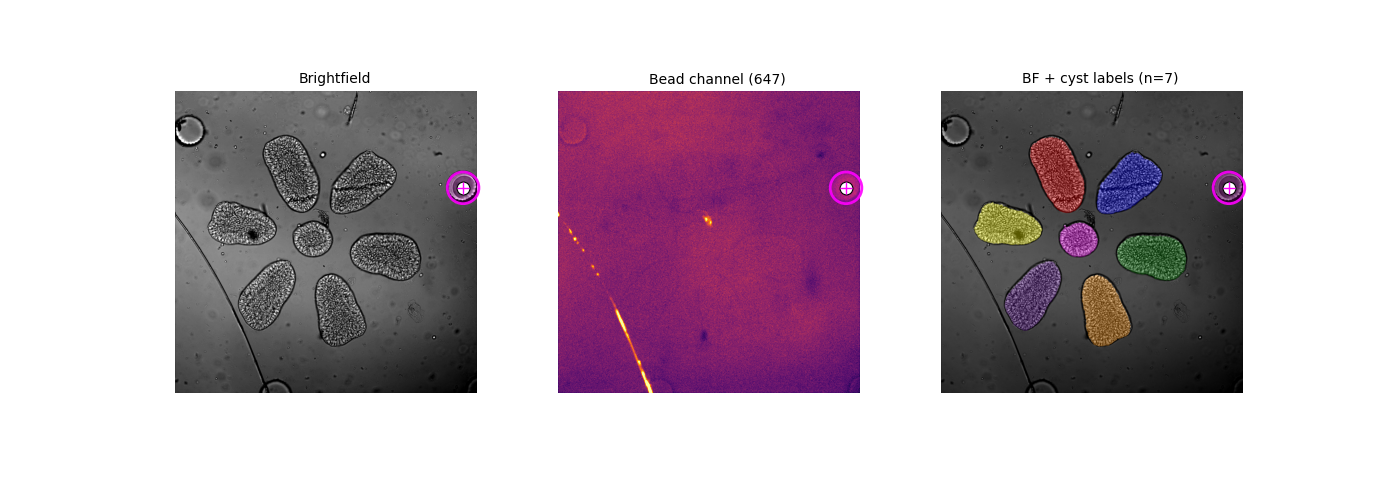

In [ ]:
# -------------------------------
# Interactive manual bead-well annotation UI
# -------------------------------
ip = get_ipython()
if ip is not None:
    try:
        ip.run_line_magic("matplotlib", "widget")
    except Exception as exc:
        print("Could not enable '%matplotlib widget'. Interactive clicks may not work.")
        print("Install ipympl if needed: pip install ipympl")
        print("Details:", exc)


class ManualBeadWellSession:
    """Simple one-click-per-scene bead-well annotation UI backed by TSV."""

    def __init__(self, scene_manifest_df: pd.DataFrame, table_path: Path, root: Path):
        self.root = Path(root)
        self.table_path = Path(table_path)
        self.df = load_or_init_bead_table(
            self.table_path, scene_manifest_df, write_if_missing=True
        )
        self.scene_indices = [int(x) for x in self.df["scene_index"].tolist()]
        self.current_pos = 0
        self.pending_point_xy = None

        # Controls
        self.scene_slider = widgets.IntSlider(
            value=0,
            min=0,
            max=max(0, len(self.scene_indices) - 1),
            step=1,
            description="Scene idx",
            continuous_update=False,
        )
        self.prev_btn = widgets.Button(description="Prev", button_style="")
        self.next_btn = widgets.Button(description="Next", button_style="")
        self.save_next_btn = widgets.Button(
            description="Save Point + Next", button_style="success"
        )
        self.pass_btn = widgets.Button(description="Pass", button_style="warning")
        self.clear_btn = widgets.Button(
            description="Clear Point", button_style="danger"
        )

        self.status_html = widgets.HTML()
        self.hint_html = widgets.HTML()
        self.log_out = widgets.Output(
            layout={
                "border": "1px solid #ddd",
                "max_height": "160px",
                "overflow": "auto",
            }
        )

        # Figure + axes (BF, bead channel, BF+cyst labels).
        self.fig, self.axes = plt.subplots(1, 3, figsize=(14, 4.8))
        self.fig.canvas.toolbar_visible = True
        self.fig.canvas.header_visible = False

        self.scene_slider.observe(self._on_slider_change, names="value")
        self.prev_btn.on_click(self._on_prev)
        self.next_btn.on_click(self._on_next)
        self.save_next_btn.on_click(self._on_save_next)
        self.pass_btn.on_click(self._on_pass)
        self.clear_btn.on_click(self._on_clear)

        self.fig.canvas.mpl_connect("button_press_event", self._on_click)

    def _now_iso(self) -> str:
        return datetime.now(timezone.utc).isoformat(timespec="seconds")

    def _log(self, msg: str) -> None:
        with self.log_out:
            print(msg)

    def _scene_row(self):
        return self.df.iloc[self.current_pos]

    def _write_table(self) -> None:
        self.df.sort_values("scene_index").to_csv(self.table_path, sep="	", index=False)

    def _current_saved_point(self):
        row = self._scene_row()
        x = row.get("bead_well_x_px", np.nan)
        y = row.get("bead_well_y_px", np.nan)
        if np.isfinite(x) and np.isfinite(y):
            return float(x), float(y)
        return None

    def _load_arrays(self, row):
        bf = tifffile.imread((self.root / row["brightfield_image_path"]).resolve())
        bead = tifffile.imread((self.root / row["bead_image_path"]).resolve())
        labels = tifffile.imread((self.root / row["cyst_labels_path"]).resolve())
        return np.asarray(bf), np.asarray(bead), np.asarray(labels).astype(np.int32)

    def _draw_point(self, x: float, y: float, radius: float) -> None:
        # Transparent magenta disk + bright edge so underlying pixels remain visible.
        for ax in self.axes:
            circ = Circle(
                (x, y),
                radius=radius,
                facecolor=(1.0, 0.0, 1.0, 0.18),
                edgecolor=(1.0, 0.0, 1.0, 0.9),
                linewidth=2.0,
            )
            ax.add_patch(circ)
            ax.scatter(
                [x],
                [y],
                s=85,
                c="white",
                edgecolors="black",
                linewidths=0.8,
                marker="o",
            )
            ax.scatter([x], [y], s=85, c="magenta", linewidths=1.0, marker="+")

    def _refresh_headers(self) -> None:
        n_total = len(self.df)
        n_annot = int(np.isfinite(self.df["bead_well_x_px"]).sum())
        n_pass = int((self.df["status"] == "passed").sum())
        n_unlabeled = int((self.df["status"] == "unlabeled").sum())

        row = self._scene_row()
        scene_idx = int(row["scene_index"])
        scene_name = str(row["scene_name"])
        status = str(row.get("status", "unlabeled"))

        self.status_html.value = f"<b>Coverage</b>: annotated={n_annot}/{n_total} | passed={n_pass} | unlabeled={n_unlabeled}"
        self.hint_html.value = (
            f"<b>Current</b>: scene {scene_idx:02d} ({scene_name}) | status={status}. "
            f"Click any panel to place bead-well centroid, then Save Point + Next."
        )

    def _render_scene(self) -> None:
        row = self._scene_row()
        bf, bead, labels = self._load_arrays(row)

        bf_disp = normalize_for_display(bf)
        bead_disp = normalize_for_display(bead)
        overlay = color.label2rgb(labels, image=bf_disp, bg_label=0, alpha=0.35)

        titles = [
            "Brightfield",
            "Bead channel (647)",
            f"BF + cyst labels (n={int(row['n_cysts_detected'])})",
        ]

        for ax in self.axes:
            ax.clear()

        self.axes[0].imshow(bf_disp, cmap="gray")
        self.axes[1].imshow(bead_disp, cmap="inferno")
        self.axes[2].imshow(np.clip(overlay, 0.0, 1.0))

        for ax, t in zip(self.axes, titles, strict=True):
            ax.set_title(t, fontsize=10)
            ax.axis("off")

        point = (
            self.pending_point_xy
            if self.pending_point_xy is not None
            else self._current_saved_point()
        )
        if point is not None:
            x, y = point
            radius = float(row.get("bead_well_radius_px", BEAD_WELL_RADIUS_PX))
            self._draw_point(x=x, y=y, radius=radius)

        self._refresh_headers()
        self.fig.canvas.draw_idle()

    def _on_click(self, event):
        if event.inaxes not in set(self.axes):
            return
        if event.xdata is None or event.ydata is None:
            return

        self.pending_point_xy = (float(event.xdata), float(event.ydata))
        self._log(
            f"Scene {int(self._scene_row()['scene_index']):02d}: pending point set to ({event.xdata:.1f}, {event.ydata:.1f})"
        )
        self._render_scene()

    def _set_scene_pos(self, new_pos: int) -> None:
        new_pos = int(np.clip(new_pos, 0, len(self.scene_indices) - 1))
        self.current_pos = new_pos
        self.scene_slider.value = new_pos
        self.pending_point_xy = None
        self._render_scene()

    def _on_slider_change(self, change):
        new_pos = int(change["new"])
        if new_pos == self.current_pos:
            return
        self.current_pos = new_pos
        self.pending_point_xy = None
        self._render_scene()

    def _on_prev(self, _):
        self._set_scene_pos(self.current_pos - 1)

    def _on_next(self, _):
        self._set_scene_pos(self.current_pos + 1)

    def _save_current(self, status: str, point_xy):
        idx = self.df.index[self.current_pos]
        if status == "annotated" and point_xy is not None:
            x, y = point_xy
            self.df.loc[idx, "bead_well_x_px"] = float(x)
            self.df.loc[idx, "bead_well_y_px"] = float(y)
            self.df.loc[idx, "status"] = "annotated"
        elif status == "passed":
            self.df.loc[idx, "bead_well_x_px"] = np.nan
            self.df.loc[idx, "bead_well_y_px"] = np.nan
            self.df.loc[idx, "status"] = "passed"
        else:
            self.df.loc[idx, "bead_well_x_px"] = np.nan
            self.df.loc[idx, "bead_well_y_px"] = np.nan
            self.df.loc[idx, "status"] = "unlabeled"

        self.df.loc[idx, "bead_well_radius_px"] = float(BEAD_WELL_RADIUS_PX)
        self.df.loc[idx, "annotator"] = os.environ.get("USER", "")
        self.df.loc[idx, "updated_at_utc"] = self._now_iso()
        self._write_table()

    def _on_save_next(self, _):
        point = (
            self.pending_point_xy
            if self.pending_point_xy is not None
            else self._current_saved_point()
        )
        if point is None:
            self._log(
                "No point set for this scene. Click a point first, or press Pass."
            )
            return

        self._save_current(status="annotated", point_xy=point)
        row = self._scene_row()
        self._log(
            f"Saved scene {int(row['scene_index']):02d} -> ({point[0]:.1f}, {point[1]:.1f})"
        )

        if self.current_pos < len(self.scene_indices) - 1:
            self._set_scene_pos(self.current_pos + 1)
        else:
            self.pending_point_xy = None
            self._render_scene()

    def _on_pass(self, _):
        row = self._scene_row()
        self._save_current(status="passed", point_xy=None)
        self.pending_point_xy = None
        self._log(
            f"Marked scene {int(row['scene_index']):02d} as passed (no coordinate)."
        )
        if self.current_pos < len(self.scene_indices) - 1:
            self._set_scene_pos(self.current_pos + 1)
        else:
            self._render_scene()

    def _on_clear(self, _):
        row = self._scene_row()
        self._save_current(status="unlabeled", point_xy=None)
        self.pending_point_xy = None
        self._log(
            f"Cleared scene {int(row['scene_index']):02d} (status set to unlabeled)."
        )
        self._render_scene()

    def render(self):
        controls = widgets.HBox(
            [
                self.prev_btn,
                self.next_btn,
                self.save_next_btn,
                self.pass_btn,
                self.clear_btn,
            ]
        )
        box = widgets.VBox(
            [
                self.scene_slider,
                controls,
                self.status_html,
                self.hint_html,
                self.log_out,
            ]
        )
        display(box)
        display(self.fig.canvas)
        self._render_scene()


manual_bead_session = ManualBeadWellSession(
    scene_manifest_df=scene_manifest_df,
    table_path=BEAD_WELL_TSV,
    root=ROOT,
)
manual_bead_session.render()

print("Annotation file:", BEAD_WELL_TSV)
print(
    "Tip: after annotation, rerun the next cells to refresh coverage, build ROI JSON, and render final montage."
)

In [ ]:
# -------------------------------
# Coverage check after manual annotation
# -------------------------------
bead_well_df = load_or_init_bead_table(
    BEAD_WELL_TSV, scene_manifest_df, write_if_missing=True
)

is_annot = np.isfinite(bead_well_df["bead_well_x_px"]) & np.isfinite(
    bead_well_df["bead_well_y_px"]
)
n_total = int(len(bead_well_df))
n_annot = int(is_annot.sum())
n_pass = int((bead_well_df["status"] == "passed").sum())
n_unlabeled = int((bead_well_df["status"] == "unlabeled").sum())

print(f"Annotated scenes: {n_annot}/{n_total}")
print(f"Passed scenes:    {n_pass}")
print(f"Unlabeled scenes: {n_unlabeled}")

display(
    bead_well_df[
        [
            "scene_index",
            "scene_name",
            "n_cysts_detected",
            "expected_cysts",
            "status",
            "bead_well_x_px",
            "bead_well_y_px",
            "updated_at_utc",
        ]
    ]
)

In [ ]:
# -------------------------------
# Build ROI JSON from (cyst polygons + manual bead-well centroids)
# -------------------------------
bead_well_df = load_or_init_bead_table(
    BEAD_WELL_TSV, scene_manifest_df, write_if_missing=True
)
annot_mask = np.isfinite(bead_well_df["bead_well_x_px"]) & np.isfinite(
    bead_well_df["bead_well_y_px"]
)
annot_df = bead_well_df.loc[annot_mask].copy().sort_values("scene_index")

if OVERWRITE_ROI_JSON:
    for p in OUT_ROI_DIR.glob("manual_s*_cyst_*.json"):
        p.unlink()

roi_summary_rows = []
n_json_written = 0

for _, row in annot_df.iterrows():
    scene_idx = int(row["scene_index"])
    bead_x = float(row["bead_well_x_px"])
    bead_y = float(row["bead_well_y_px"])
    pixel_um = float(row["pixel_size_um"])

    labels_path = (ROOT / row["cyst_labels_path"]).resolve()
    labels = tifffile.imread(labels_path).astype(np.int32)
    props = measure.regionprops(labels)

    for i, region in enumerate(props, start=1):
        mask = labels == int(region.label)
        poly = mask_to_polygon_xy(mask, simplify_tolerance_px=1.5)
        if len(poly) < 3:
            continue

        cyst_id = f"manual_s{scene_idx:02d}_cyst_{i:04d}"
        rec = {
            "cyst_id": cyst_id,
            "source_file": str(row["source_file"]),
            "scene": str(row["scene"]),
            "scene_index": int(scene_idx),
            "pixel_size_um": float(pixel_um),
            "psmad_image_path": str(row["psmad_image_path"]),
            "dapi_image_path": str(row["dapi_image_path"]),
            "bead_image_path": str(row["bead_image_path"]),
            "bead_xy_px": [float(bead_x), float(bead_y)],
            "polygon_xy_px": poly,
            "roi_method": "auto_cyst_manual_bead_well_notebook",
            "roi_area_px": int(region.area),
            "roi_centroid_xy_px": [
                float(region.centroid[1]),
                float(region.centroid[0]),
            ],
        }

        out_json = OUT_ROI_DIR / f"{cyst_id}.json"
        out_json.write_text(json.dumps(rec, indent=2), encoding="utf-8")
        n_json_written += 1

        roi_summary_rows.append(
            {
                "cyst_id": cyst_id,
                "source_file": str(row["source_file"]),
                "scene": str(row["scene"]),
                "scene_index": int(scene_idx),
                "roi_area_px": int(region.area),
                "centroid_x_px": float(region.centroid[1]),
                "centroid_y_px": float(region.centroid[0]),
                "bead_well_x_px": float(bead_x),
                "bead_well_y_px": float(bead_y),
                "dapi_image_path": str(row["dapi_image_path"]),
                "psmad_image_path": str(row["psmad_image_path"]),
                "roi_json_path": rel_to_root(out_json),
            }
        )


roi_summary_columns = [
    "cyst_id",
    "source_file",
    "scene",
    "scene_index",
    "roi_area_px",
    "centroid_x_px",
    "centroid_y_px",
    "bead_well_x_px",
    "bead_well_y_px",
    "dapi_image_path",
    "psmad_image_path",
    "roi_json_path",
]

roi_summary_df = pd.DataFrame(roi_summary_rows, columns=roi_summary_columns)
roi_summary_df.to_csv(ROI_SUMMARY_TSV, sep="	", index=False)

print("Bead position TSV:", BEAD_WELL_TSV)
print("ROI summary TSV:", ROI_SUMMARY_TSV)
print("ROI JSON directory:", OUT_ROI_DIR)
print("Scenes with manual bead coordinates:", len(annot_df))
print("ROI JSON files written:", n_json_written)

display(roi_summary_df.head(20) if len(roi_summary_df) else roi_summary_df)

In [ ]:
# -------------------------------
# Final all-scene preview: cyst labels + manual bead-well marker
# -------------------------------
bead_well_df = load_or_init_bead_table(
    BEAD_WELL_TSV, scene_manifest_df, write_if_missing=True
)
bead_lookup = {int(r.scene_index): r for r in bead_well_df.itertuples(index=False)}

final_items = []
for row in scene_manifest_df.itertuples(index=False):
    scene_idx = int(row.scene_index)
    bf = tifffile.imread((ROOT / row.brightfield_image_path).resolve())
    labels = tifffile.imread((ROOT / row.cyst_labels_path).resolve()).astype(np.int32)

    rgb = color.label2rgb(
        labels, image=normalize_for_display(bf), bg_label=0, alpha=0.35
    )
    rgb = np.clip(rgb, 0.0, 1.0)

    ann = bead_lookup.get(scene_idx, None)
    has_bead = False
    status = "unlabeled"
    if ann is not None:
        status = str(getattr(ann, "status", "unlabeled"))
        x = getattr(ann, "bead_well_x_px", np.nan)
        y = getattr(ann, "bead_well_y_px", np.nan)
        if np.isfinite(x) and np.isfinite(y):
            has_bead = True
            r = float(getattr(ann, "bead_well_radius_px", BEAD_WELL_RADIUS_PX))

            # Very light transparent fill so cyst labels remain easy to see.
            rr_fill, cc_fill = draw.disk(
                (float(y), float(x)), radius=max(4.0, r), shape=rgb.shape[:2]
            )
            rgb[rr_fill, cc_fill] = 0.96 * rgb[rr_fill, cc_fill] + 0.04 * np.array(
                [1.0, 0.0, 1.0], dtype=np.float32
            )

            # Soft ring for visibility (blended, not hard-painted).
            rr_o, cc_o = draw.disk(
                (float(y), float(x)), radius=max(4.0, r + 2.5), shape=rgb.shape[:2]
            )
            rr_i, cc_i = draw.disk(
                (float(y), float(x)), radius=max(2.0, r - 2.5), shape=rgb.shape[:2]
            )
            ring_outer = np.zeros(rgb.shape[:2], dtype=bool)
            ring_inner = np.zeros(rgb.shape[:2], dtype=bool)
            ring_outer[rr_o, cc_o] = True
            ring_inner[rr_i, cc_i] = True
            ring_mask = ring_outer & (~ring_inner)
            rgb[ring_mask] = 0.65 * rgb[ring_mask] + 0.35 * np.array(
                [1.0, 0.0, 1.0], dtype=np.float32
            )

            # Subtle center indicator (light blend only).
            rr_c, cc_c = draw.disk(
                (float(y), float(x)), radius=3.0, shape=rgb.shape[:2]
            )
            rgb[rr_c, cc_c] = 0.85 * rgb[rr_c, cc_c] + 0.15 * np.array(
                [1.0, 1.0, 1.0], dtype=np.float32
            )

    ds = max(1, int(SCENE_OVERLAY_DOWNSAMPLE))
    preview = (np.clip(rgb[::ds, ::ds], 0.0, 1.0) * 255).astype(np.uint8)
    final_items.append(
        {
            "scene_index": scene_idx,
            "n_cysts": int(row.n_cysts_detected),
            "status": status,
            "has_bead": bool(has_bead),
            "image": preview,
        }
    )

final_items = sorted(final_items, key=lambda d: d["scene_index"])
n = len(final_items)
ncols = max(1, int(SCENE_OVERLAY_GRID_COLS))
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.1 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, item in zip(axes, final_items):
    ax.imshow(item["image"])
    bead_tag = "Y" if item["has_bead"] else "N"
    tcol = "black" if item["has_bead"] else "red"
    ax.set_title(
        f"S{item['scene_index']:02d} | c={item['n_cysts']} | bead={bead_tag} ({item['status']})",
        fontsize=8,
        color=tcol,
    )
    ax.axis("off")

for ax in axes[len(final_items) :]:
    ax.axis("off")

fig.suptitle(
    "Final QA: BF + cyst labels + manual bead-well marker (transparent magenta fill)",
    fontsize=11,
)
plt.tight_layout()
plt.show()